In [1]:
#imports
import os
import csv
import torch
from data_loader_dkl_local import get_supervised_loader
from train_vae_dkl import (
    build_vae_dkl,
    build_vae_dkl_optimizer,
    train_vae_dkl_epoch,
    evaluate_latent_health,
    evaluate_full,
    get_lengthscales,
    plot_lengthscales,
    get_gp_hyperparams,
    plot_gp_evolution,
    plot_training_history,
    plot_prediction_diagnostics,
    plot_sweep_summary,
)
from likelihoods_dkl import build_likelihood
from bond_dkl_v5 import build_mll, get_train_y_mean


In [2]:
#set up
EPOCHS = 10
NUM_INDUCING = 500
LATENT_DIM = 6
HIDDEN_DIMS = [64, 16]
NU = 1.5
BETA = 0.05
PRINT_EVERY = 200

train_parquet = "master_panel_train_std.parquet"
test_parquet = "master_panel_test_std.parquet"
if not os.path.exists(train_parquet):
    raise FileNotFoundError(f"Cannot find {train_parquet} in current working directory.")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"[Setup] Device: {device}")


[Setup] Device: cuda


In [3]:
# 2 kings x 3 likelihoods

SWEEP_GRID = [
    {"name": "v10-a1_kingA_gaussian",       "lambda_ls": 0.00, "penalty_mode": "mean", "likelihood": "gaussian"},
    {"name": "v10-a2_kingA_heteroscedastic","lambda_ls": 0.00, "penalty_mode": "mean", "likelihood": "heteroscedastic"},
    {"name": "v10-a3_kingA_studentt",       "lambda_ls": 0.00, "penalty_mode": "mean", "likelihood": "studentt"},
    {"name": "v10-b1_kingB_gaussian",       "lambda_ls": 0.02, "penalty_mode": "mean", "likelihood": "gaussian"},
    {"name": "v10-b2_kingB_heteroscedastic","lambda_ls": 0.02, "penalty_mode": "mean", "likelihood": "heteroscedastic"},
    {"name": "v10-b3_kingB_studentt",       "lambda_ls": 0.02, "penalty_mode": "mean", "likelihood": "studentt"},
]


In [4]:
# data loading
train_loader, num_features = get_supervised_loader(
    parquet_path=train_parquet, batch_size=4096, num_workers=3,
)
print(f"[Setup] Feature count: {num_features}")

has_test = os.path.exists(test_parquet)
if has_test:
    train_y_mean = get_train_y_mean(train_parquet)
else:
    print(f"[Setup] WARNING: {test_parquet} not found -- RMSE/tail metrics will be skipped.")


[Setup] Feature count: 64



Running v10-a1_kingA_gaussian  (lambda_ls=0.0, likelihood=gaussian)
    batch 200: gp_loss=-0.3016  kl_loss=1.4780
    batch 400: gp_loss=-1.3700  kl_loss=1.3959
    batch 600: gp_loss=-2.2107  kl_loss=1.8009
    batch 800: gp_loss=-2.5664  kl_loss=1.9231
    batch 1000: gp_loss=-2.7425  kl_loss=1.8305
    batch 1200: gp_loss=-2.7375  kl_loss=1.7836
    batch 1400: gp_loss=-2.8975  kl_loss=1.7911
    batch 1600: gp_loss=-2.8122  kl_loss=1.7477
    batch 1800: gp_loss=-2.9672  kl_loss=1.6700
    batch 2000: gp_loss=-2.9339  kl_loss=1.6292
    batch 2200: gp_loss=-2.9241  kl_loss=1.6661
    batch 2400: gp_loss=-2.9691  kl_loss=1.6399
    batch 2600: gp_loss=-2.6692  kl_loss=1.6220
    batch 2800: gp_loss=-2.9893  kl_loss=1.5345
  epoch 01/10: gp_loss=-2.4064  kl_loss=1.6447  ls_penalty=0.0000  active_dims=4
    batch 200: gp_loss=-3.0060  kl_loss=1.5465
    batch 400: gp_loss=-2.9996  kl_loss=1.5159
    batch 600: gp_loss=-3.0133  kl_loss=1.5228
    batch 800: gp_loss=-3.0109  kl_loss=1

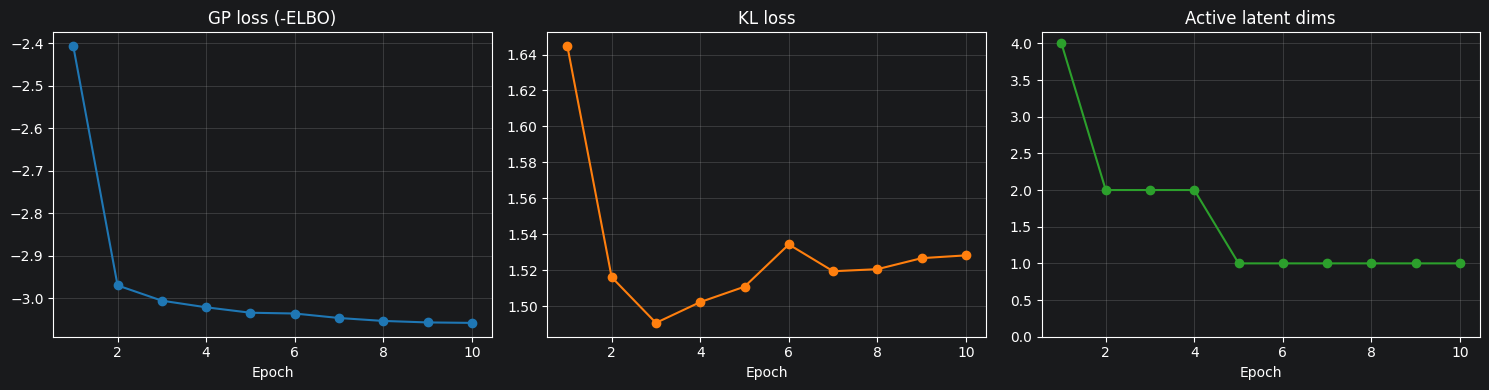

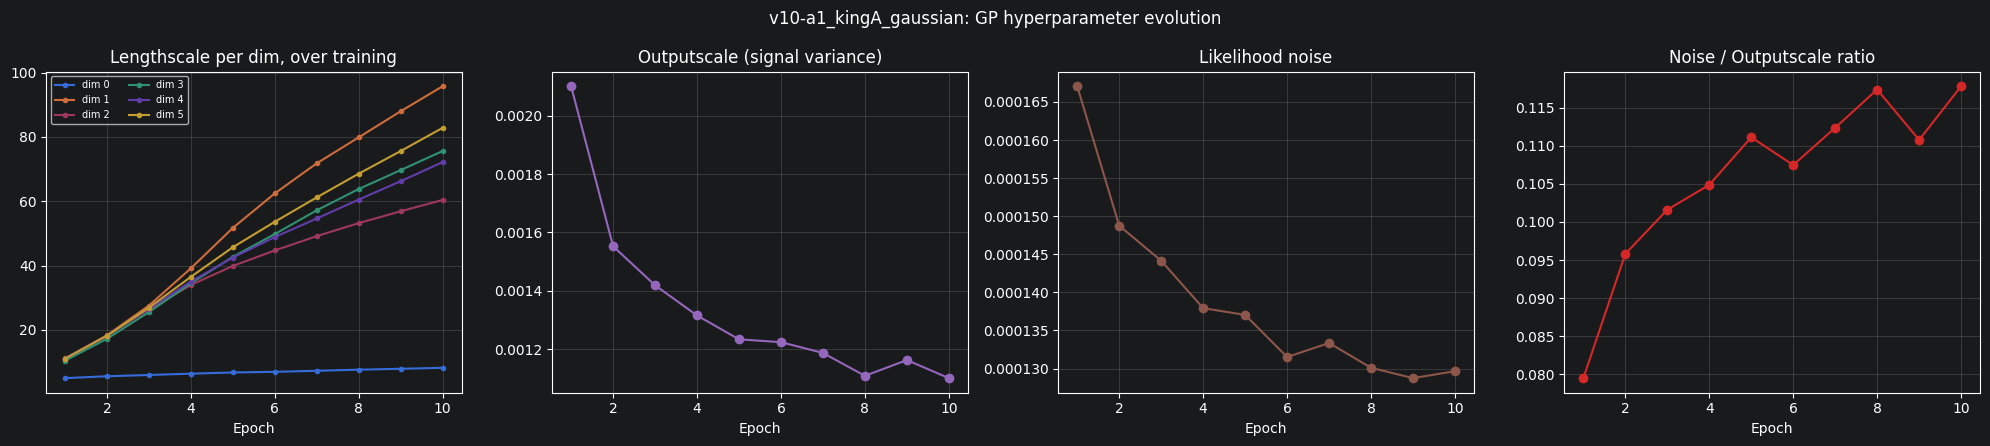

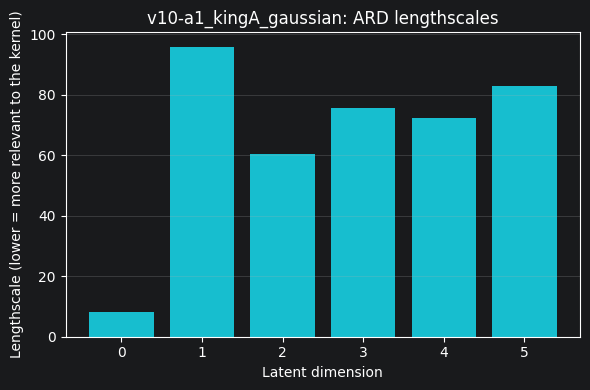

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


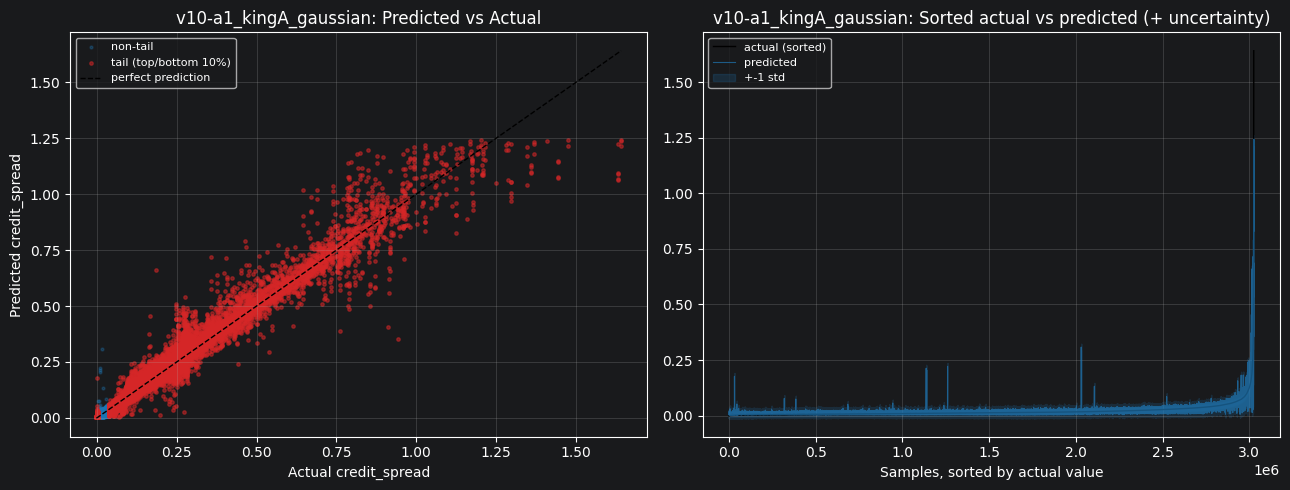

  RMSE overall=0.00440  low_tail=0.00441  high_tail=0.01096  within_1std=99.6%

Running v10-a2_kingA_heteroscedastic  (lambda_ls=0.0, likelihood=heteroscedastic)
    batch 200: gp_loss=-2.7001  kl_loss=12.0457
    batch 400: gp_loss=-2.8715  kl_loss=12.0692
    batch 600: gp_loss=-2.9497  kl_loss=12.0628
    batch 800: gp_loss=-2.9319  kl_loss=10.3262
    batch 1000: gp_loss=-2.9175  kl_loss=6.3881
    batch 1200: gp_loss=-2.9367  kl_loss=3.4022
    batch 1400: gp_loss=-2.9805  kl_loss=2.3347
    batch 1600: gp_loss=-3.0062  kl_loss=1.9327
    batch 1800: gp_loss=-3.0403  kl_loss=1.7465
    batch 2000: gp_loss=-3.0442  kl_loss=1.7083
    batch 2200: gp_loss=-3.0477  kl_loss=1.6823
    batch 2400: gp_loss=-3.0474  kl_loss=1.6292
    batch 2600: gp_loss=-3.0776  kl_loss=1.5720
    batch 2800: gp_loss=-3.0702  kl_loss=1.5844
  epoch 01/10: gp_loss=-2.8657  kl_loss=4.9148  ls_penalty=0.0000  active_dims=2
    batch 200: gp_loss=-3.0724  kl_loss=1.6204
    batch 400: gp_loss=-3.0727  kl_los

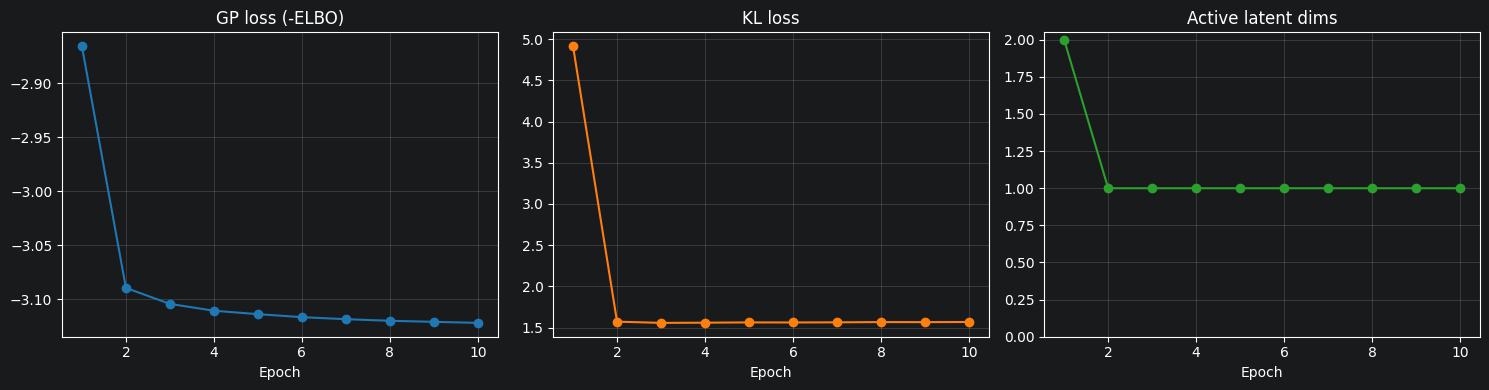

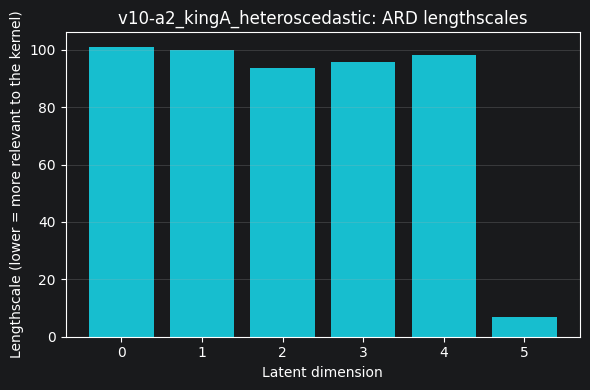

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


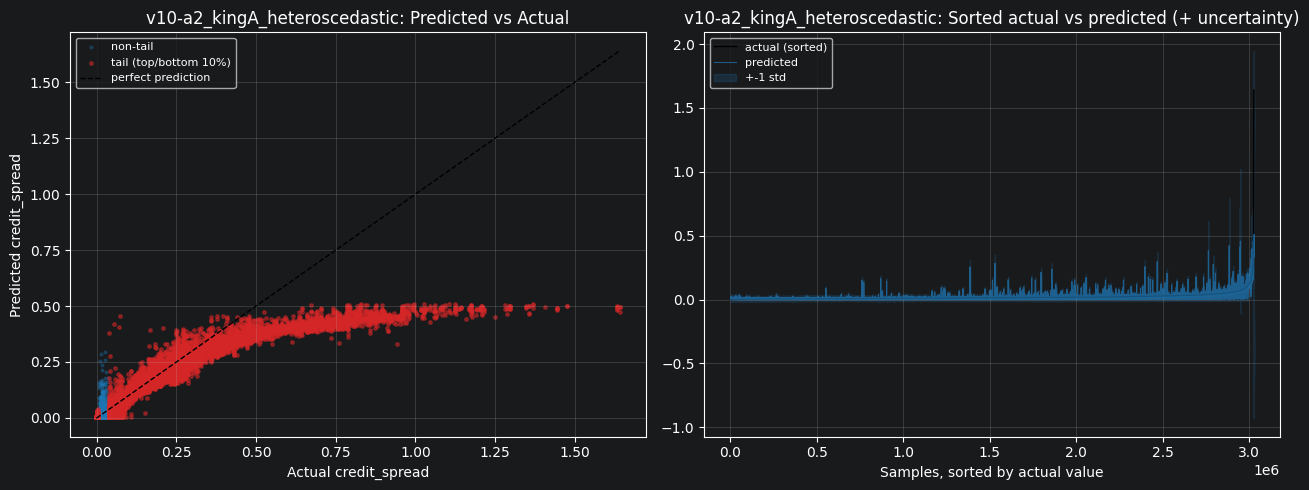

  RMSE overall=0.00905  low_tail=0.00221  high_tail=0.02762  within_1std=99.8%

Running v10-a3_kingA_studentt  (lambda_ls=0.0, likelihood=studentt)
    batch 200: gp_loss=-1.5266  kl_loss=5.9425
    batch 400: gp_loss=-2.7199  kl_loss=7.9431
    batch 600: gp_loss=-2.8301  kl_loss=5.2371
    batch 800: gp_loss=-2.8886  kl_loss=3.1833
    batch 1000: gp_loss=-2.9295  kl_loss=2.1873
    batch 1200: gp_loss=-2.9598  kl_loss=1.8280
    batch 1400: gp_loss=-2.9899  kl_loss=1.6532
    batch 1600: gp_loss=-3.0037  kl_loss=1.6352
    batch 1800: gp_loss=-3.0193  kl_loss=1.5455
    batch 2000: gp_loss=-3.0358  kl_loss=1.5519
    batch 2200: gp_loss=-3.0300  kl_loss=1.6136
    batch 2400: gp_loss=-3.0295  kl_loss=1.5610
    batch 2600: gp_loss=-3.0394  kl_loss=1.5783
    batch 2800: gp_loss=-3.0320  kl_loss=1.5861
  epoch 01/10: gp_loss=-2.7390  kl_loss=2.7362  ls_penalty=0.0000  active_dims=1
    batch 200: gp_loss=-3.0288  kl_loss=1.6283
    batch 400: gp_loss=-3.0602  kl_loss=1.5206
    batch

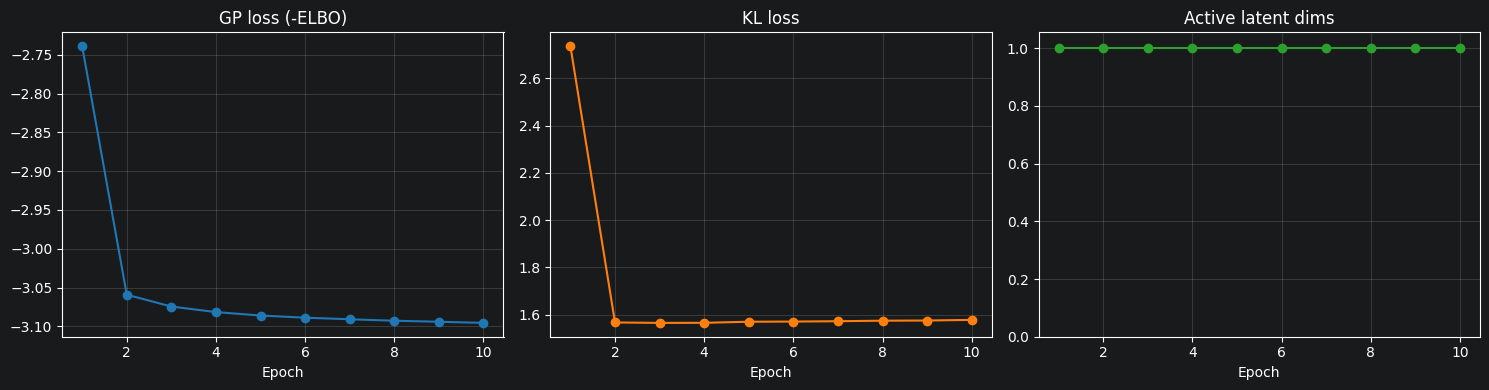

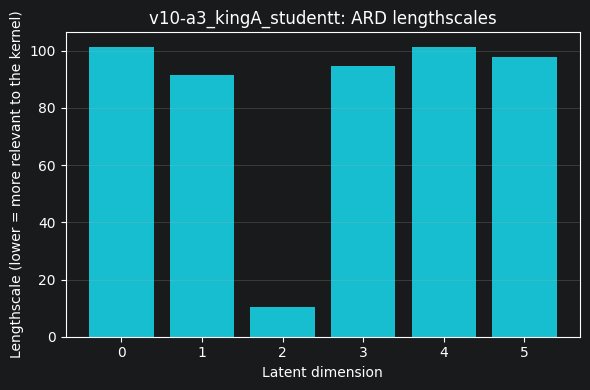

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


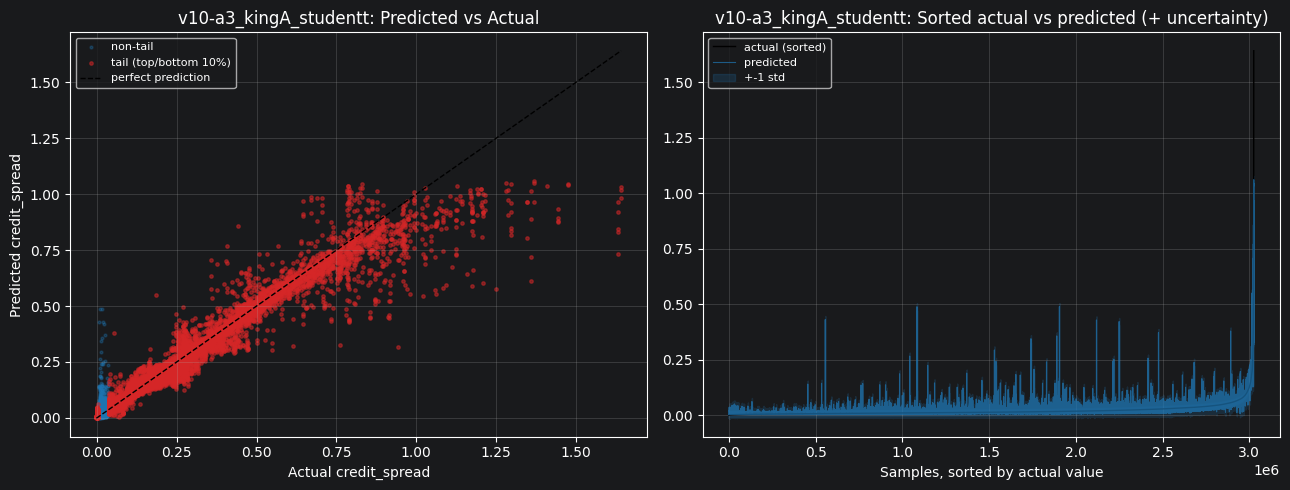

  RMSE overall=0.00464  low_tail=0.00259  high_tail=0.01257  within_1std=99.7%

Running v10-b1_kingB_gaussian  (lambda_ls=0.02, likelihood=gaussian)
    batch 200: gp_loss=-0.2953  kl_loss=1.5322
    batch 400: gp_loss=-1.3608  kl_loss=1.4957
    batch 600: gp_loss=-2.1692  kl_loss=1.8391
    batch 800: gp_loss=-2.5280  kl_loss=2.2446
    batch 1000: gp_loss=-2.7769  kl_loss=2.1323
    batch 1200: gp_loss=-2.8351  kl_loss=2.0472
    batch 1400: gp_loss=-2.8987  kl_loss=1.9110
    batch 1600: gp_loss=-2.8255  kl_loss=2.0012
    batch 1800: gp_loss=-2.9171  kl_loss=1.8781
    batch 2000: gp_loss=-2.9229  kl_loss=1.8466
    batch 2200: gp_loss=-2.9302  kl_loss=1.8225
    batch 2400: gp_loss=-2.8925  kl_loss=1.8306
    batch 2600: gp_loss=-2.9637  kl_loss=1.7694
    batch 2800: gp_loss=-2.9260  kl_loss=1.8011
  epoch 01/10: gp_loss=-2.3821  kl_loss=1.8247  ls_penalty=4.4871  active_dims=6
    batch 200: gp_loss=-2.8439  kl_loss=1.8446
    batch 400: gp_loss=-2.9036  kl_loss=1.7446
    batc

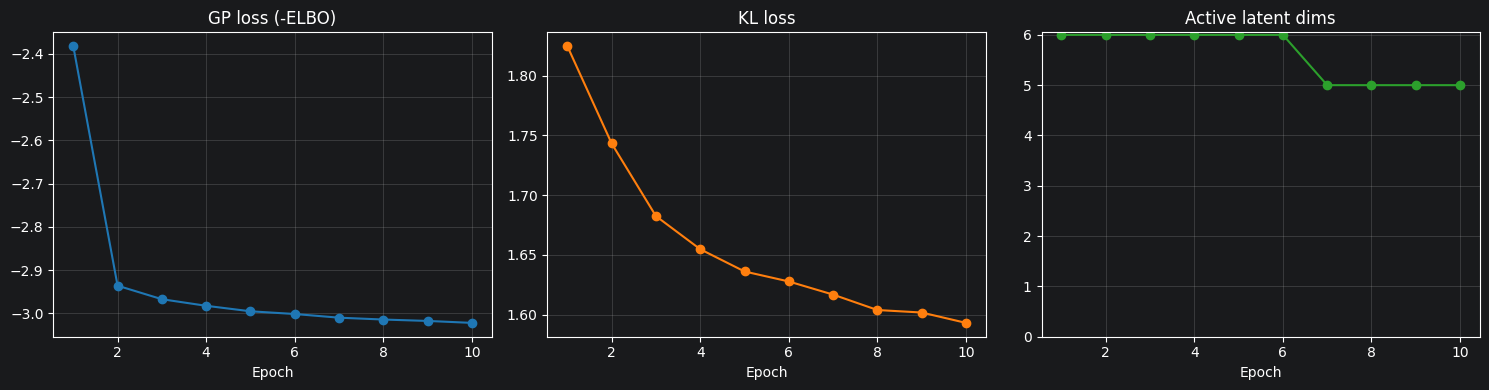

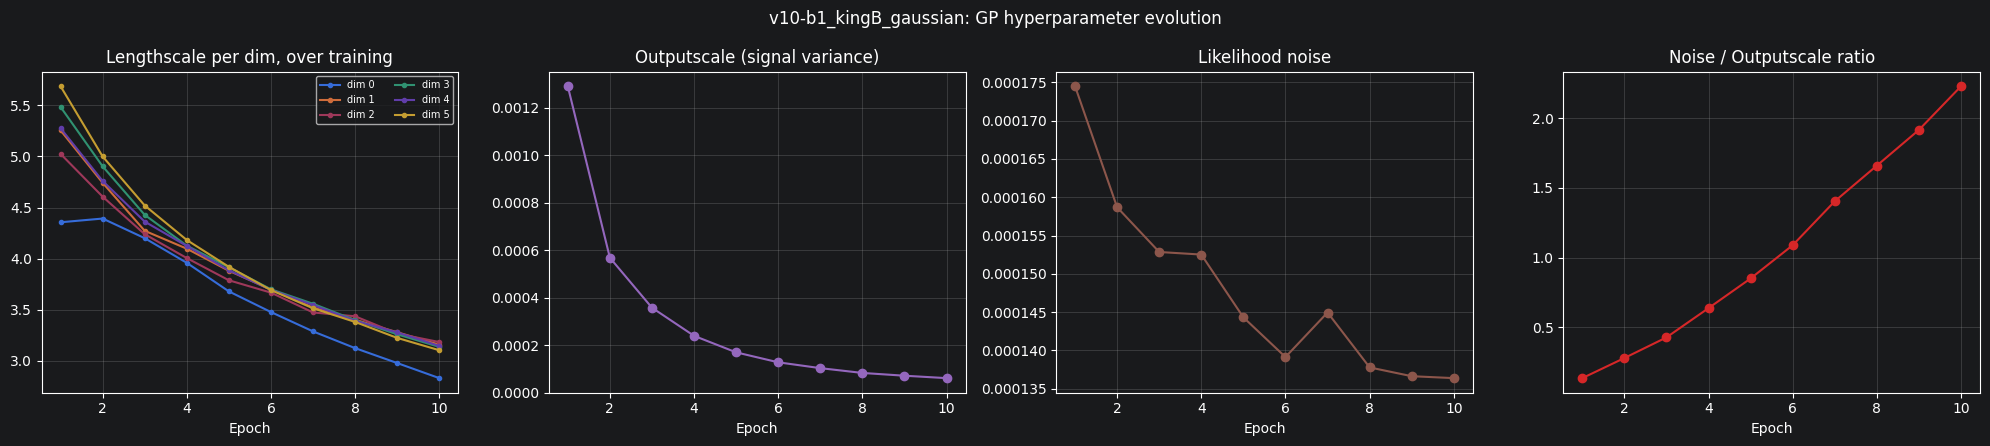

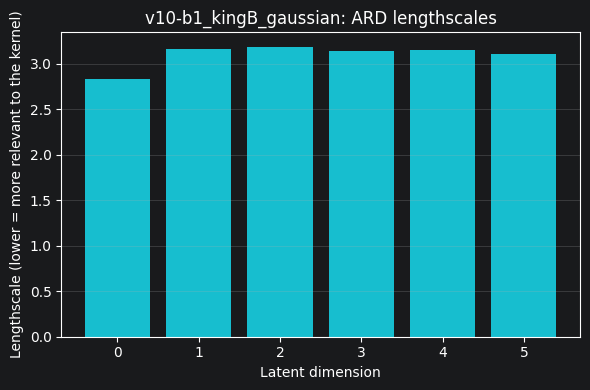

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


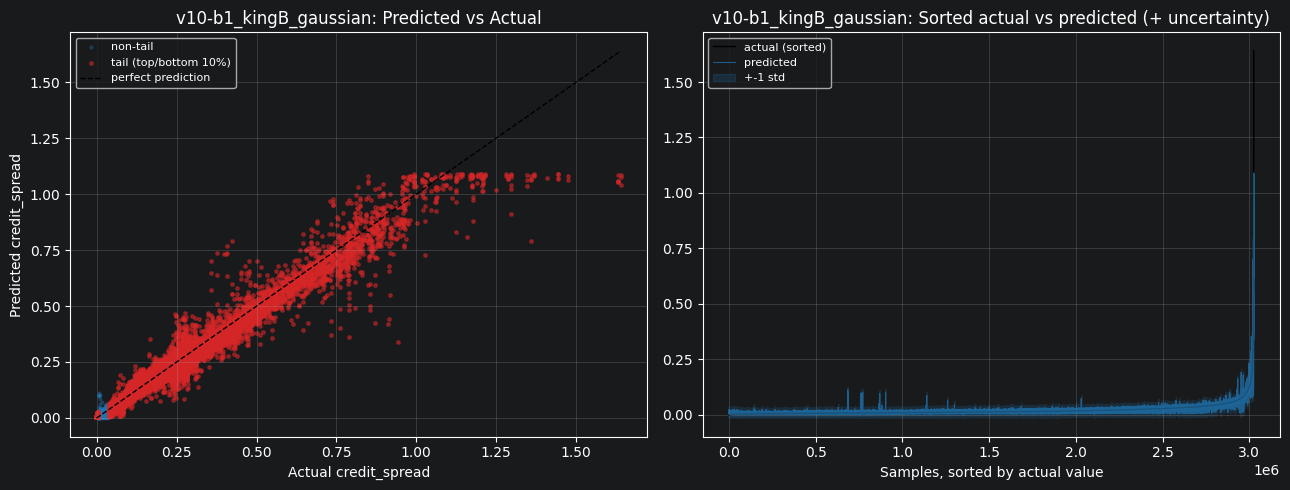

  RMSE overall=0.00403  low_tail=0.00245  high_tail=0.01078  within_1std=99.6%

Running v10-b2_kingB_heteroscedastic  (lambda_ls=0.02, likelihood=heteroscedastic)
    batch 200: gp_loss=-2.6976  kl_loss=12.0321
    batch 400: gp_loss=-2.8772  kl_loss=12.0603
    batch 600: gp_loss=-2.9377  kl_loss=12.0608
    batch 800: gp_loss=-2.9684  kl_loss=11.5176
    batch 1000: gp_loss=-2.8817  kl_loss=6.0143
    batch 1200: gp_loss=-2.9272  kl_loss=3.7037
    batch 1400: gp_loss=-2.9599  kl_loss=2.5444
    batch 1600: gp_loss=-2.9922  kl_loss=2.0161
    batch 1800: gp_loss=-3.0121  kl_loss=1.8050
    batch 2000: gp_loss=-3.0348  kl_loss=1.7049
    batch 2200: gp_loss=-3.0539  kl_loss=1.6357
    batch 2400: gp_loss=-3.0447  kl_loss=1.6247
    batch 2600: gp_loss=-3.0522  kl_loss=1.6668
    batch 2800: gp_loss=-3.0580  kl_loss=1.5644
  epoch 01/10: gp_loss=-2.8586  kl_loss=5.0183  ls_penalty=3.1466  active_dims=4
    batch 200: gp_loss=-3.0438  kl_loss=1.5815
    batch 400: gp_loss=-3.0666  kl_lo

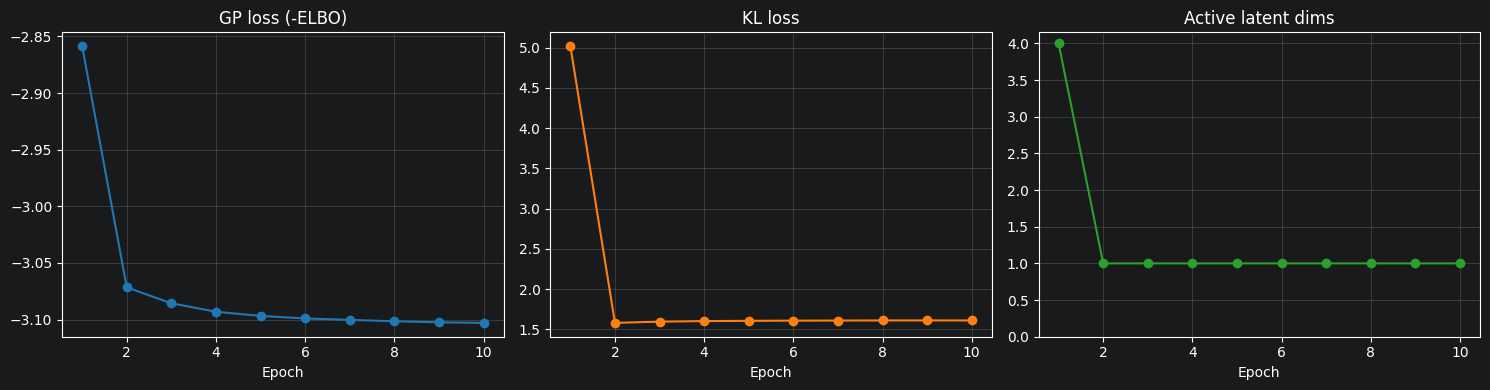

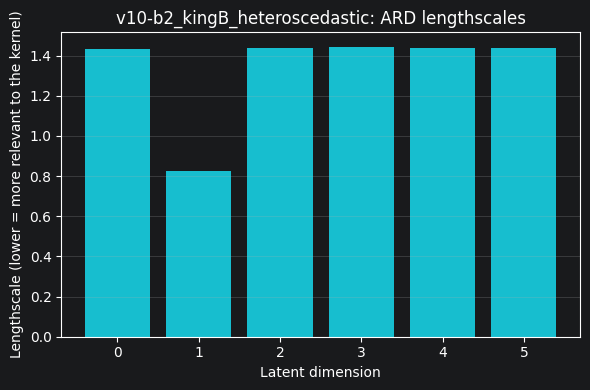

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


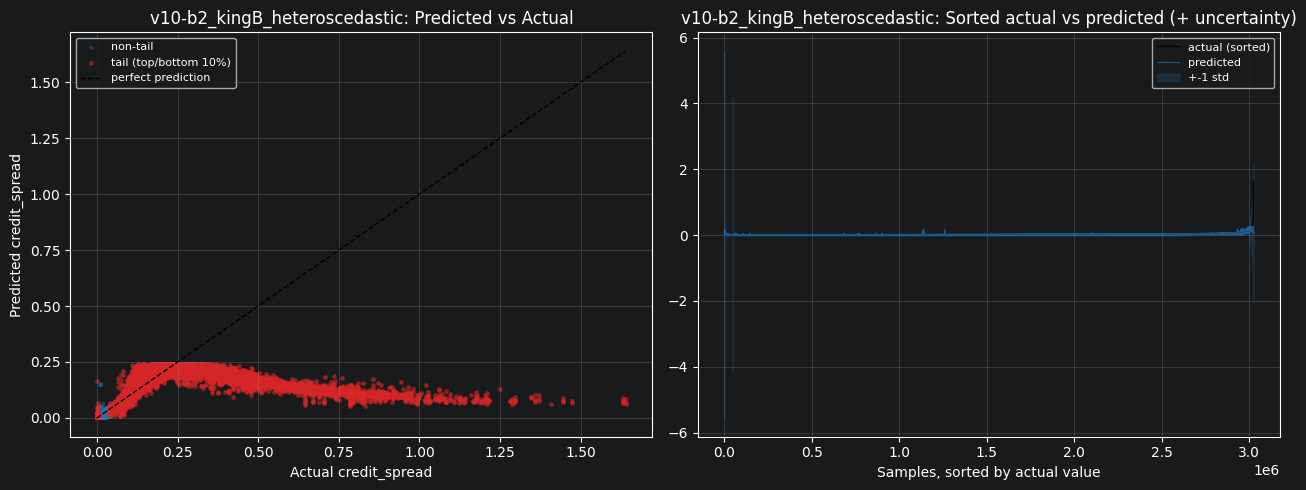

  RMSE overall=0.01636  low_tail=0.00308  high_tail=0.05125  within_1std=99.8%

Running v10-b3_kingB_studentt  (lambda_ls=0.02, likelihood=studentt)
    batch 200: gp_loss=-1.5607  kl_loss=6.1560
    batch 400: gp_loss=-2.7108  kl_loss=8.4312
    batch 600: gp_loss=-2.8077  kl_loss=5.7526
    batch 800: gp_loss=-2.8670  kl_loss=3.6160
    batch 1000: gp_loss=-2.9133  kl_loss=2.4223
    batch 1200: gp_loss=-2.9411  kl_loss=1.9269
    batch 1400: gp_loss=-2.9747  kl_loss=1.7138
    batch 1600: gp_loss=-2.9678  kl_loss=1.6980
    batch 1800: gp_loss=-2.9951  kl_loss=1.5746
    batch 2000: gp_loss=-2.9935  kl_loss=1.6356
    batch 2200: gp_loss=-2.9996  kl_loss=1.5829
    batch 2400: gp_loss=-3.0107  kl_loss=1.6014
    batch 2600: gp_loss=-3.0310  kl_loss=1.5461
    batch 2800: gp_loss=-3.0195  kl_loss=1.5618
  epoch 01/10: gp_loss=-2.7249  kl_loss=2.8794  ls_penalty=3.7398  active_dims=1
    batch 200: gp_loss=-3.0207  kl_loss=1.5847
    batch 400: gp_loss=-3.0408  kl_loss=1.5657
    batc

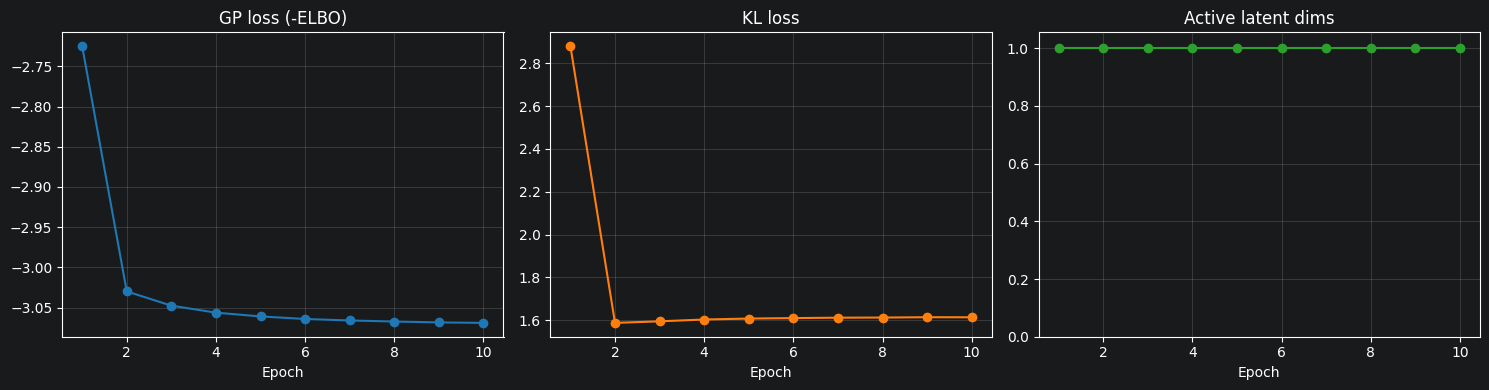

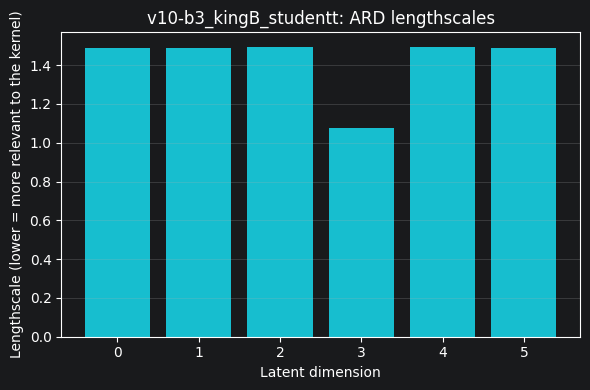

C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:339: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Tawhe\Documents\Real Documents\dissrun\v10\files\train_vae_dkl.py:341: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=120)
C:\Users\Tawhe\Documents\Real Documents\dissrun\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


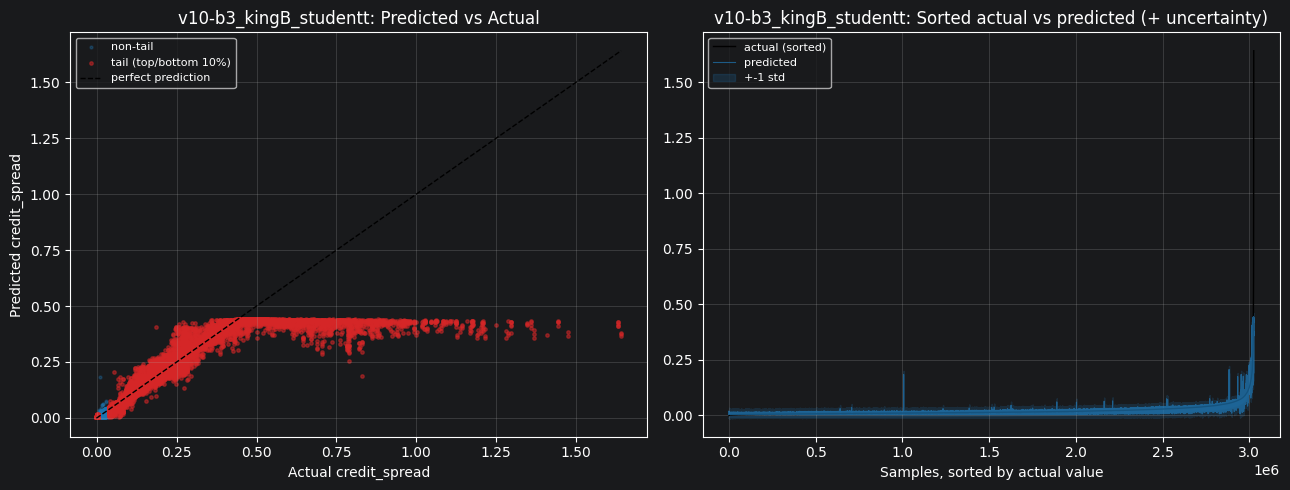

  RMSE overall=0.00937  low_tail=0.00224  high_tail=0.02881  within_1std=99.7%


In [5]:
# running sweep
sweep_results = []
os.makedirs("v10_plots", exist_ok=True)

for cfg in SWEEP_GRID:
    print("\n" + "=" * 70)
    print(f"Running {cfg['name']}  (lambda_ls={cfg['lambda_ls']}, likelihood={cfg['likelihood']})")
    print("=" * 70)

    model, likelihood = build_vae_dkl(
        input_dim=num_features,
        latent_dim=LATENT_DIM,
        num_inducing_points=NUM_INDUCING,
        nu=NU,
        hidden_dims=HIDDEN_DIMS,
        device=device,
    )

    likelihood = build_likelihood(cfg['likelihood'], LATENT_DIM, device=device)

    optimizer = build_vae_dkl_optimizer(model, likelihood)
    mll, num_data = build_mll(model, likelihood, train_parquet)

    history = {'epoch': [], 'gp_loss': [], 'kl_loss': [], 'n_active': []}
    gp_history = {'epoch': [], 'lengthscales': [], 'outputscale': [], 'noise': [], 'mean_constant': []}
    for epoch in range(1, EPOCHS + 1):
        gp_loss, kl_loss, ls_mean = train_vae_dkl_epoch(
            model, likelihood, optimizer, mll, train_loader,
            beta=BETA, lambda_ls=cfg['lambda_ls'], penalty_mode=cfg['penalty_mode'],
            device=device, print_every=PRINT_EVERY,
        )
        _, n_active = evaluate_latent_health(model, train_loader, device=device,
                                              max_samples=20000, verbose=False)
        history['epoch'].append(epoch)
        history['gp_loss'].append(gp_loss)
        history['kl_loss'].append(kl_loss)
        history['n_active'].append(n_active)

        # get_gp_hyperparams reads likelihood.noise directly, doesn't exist for other
        # likelihoods, skipped for non-Gaussian models.
        if cfg['likelihood'] == 'gaussian':
            gp_snap = get_gp_hyperparams(model, likelihood)
            gp_history['epoch'].append(epoch)
            gp_history['lengthscales'].append(gp_snap['lengthscales'])
            gp_history['outputscale'].append(gp_snap['outputscale'])
            gp_history['noise'].append(gp_snap['noise'])
            gp_history['mean_constant'].append(gp_snap['mean_constant'])

        print(f"  epoch {epoch:02d}/{EPOCHS}: gp_loss={gp_loss:.4f}  kl_loss={kl_loss:.4f}  "
              f"ls_penalty={ls_mean:.4f}  active_dims={n_active}")

    plot_training_history(history, save_path=f"v10_plots/{cfg['name']}_history.png")
    if cfg['likelihood'] == 'gaussian' and len(gp_history['epoch']) > 0:
        plot_gp_evolution(gp_history, cfg['name'], save_path=f"v10_plots/{cfg['name']}_gp_evolution.png")

    lengthscales = get_lengthscales(model)
    plot_lengthscales(lengthscales, cfg['name'], save_path=f"v10_plots/{cfg['name']}_lengthscales.png")

    result_row = {
        "name": cfg['name'], "likelihood": cfg['likelihood'], "lambda_ls": cfg['lambda_ls'],
        "final_gp_loss": history['gp_loss'][-1], "final_kl_loss": history['kl_loss'][-1],
        "n_active": history['n_active'][-1],
        "lengthscale_mean": float(lengthscales.mean()),
    }

    if has_test:
        test_loader, _ = get_supervised_loader(
            parquet_path=test_parquet, batch_size=4096, num_workers=3,
        )
        eval_results = evaluate_full(model, likelihood, test_loader, train_y_mean, device=device)
        plot_prediction_diagnostics(eval_results, cfg['name'],
                                     save_path=f"v10_plots/{cfg['name']}_predictions.png")

        result_row.update({
            "rmse_overall": eval_results['rmse_overall'],
            "rmse_low_tail": eval_results['rmse_low_tail'],
            "rmse_high_tail": eval_results['rmse_high_tail'],
            "baseline_rmse": eval_results['baseline_rmse'],
            "beats_baseline": eval_results['beats_baseline'],
            "within_1std_pct": eval_results['within_1std_pct'],
        })
        print(f"  RMSE overall={eval_results['rmse_overall']:.5f}  "
              f"low_tail={eval_results['rmse_low_tail']:.5f}  "
              f"high_tail={eval_results['rmse_high_tail']:.5f}  "
              f"within_1std={eval_results['within_1std_pct']:.1%}")

    sweep_results.append(result_row)



Saved full results table to v10_sweep_results.csv
{'name': 'v10-a1_kingA_gaussian', 'likelihood': 'gaussian', 'lambda_ls': 0.0, 'final_gp_loss': -3.05782596046186, 'final_kl_loss': 1.528240015770754, 'n_active': 1, 'lengthscale_mean': 65.85616302490234, 'rmse_overall': 0.0043981559574604034, 'rmse_low_tail': 0.004413512535393238, 'rmse_high_tail': 0.010957715101540089, 'baseline_rmse': 0.029028125367752546, 'beats_baseline': True, 'within_1std_pct': 0.9963075277786407}
{'name': 'v10-a2_kingA_heteroscedastic', 'likelihood': 'heteroscedastic', 'lambda_ls': 0.0, 'final_gp_loss': -3.1220901542869597, 'final_kl_loss': 1.5682412102899475, 'n_active': 1, 'lengthscale_mean': 82.54991149902344, 'rmse_overall': 0.009048624895513058, 'rmse_low_tail': 0.0022114140447229147, 'rmse_high_tail': 0.027615856379270554, 'baseline_rmse': 0.02902812536775254, 'beats_baseline': True, 'within_1std_pct': 0.9975418769907393}
{'name': 'v10-a3_kingA_studentt', 'likelihood': 'studentt', 'lambda_ls': 0.0, 'final_

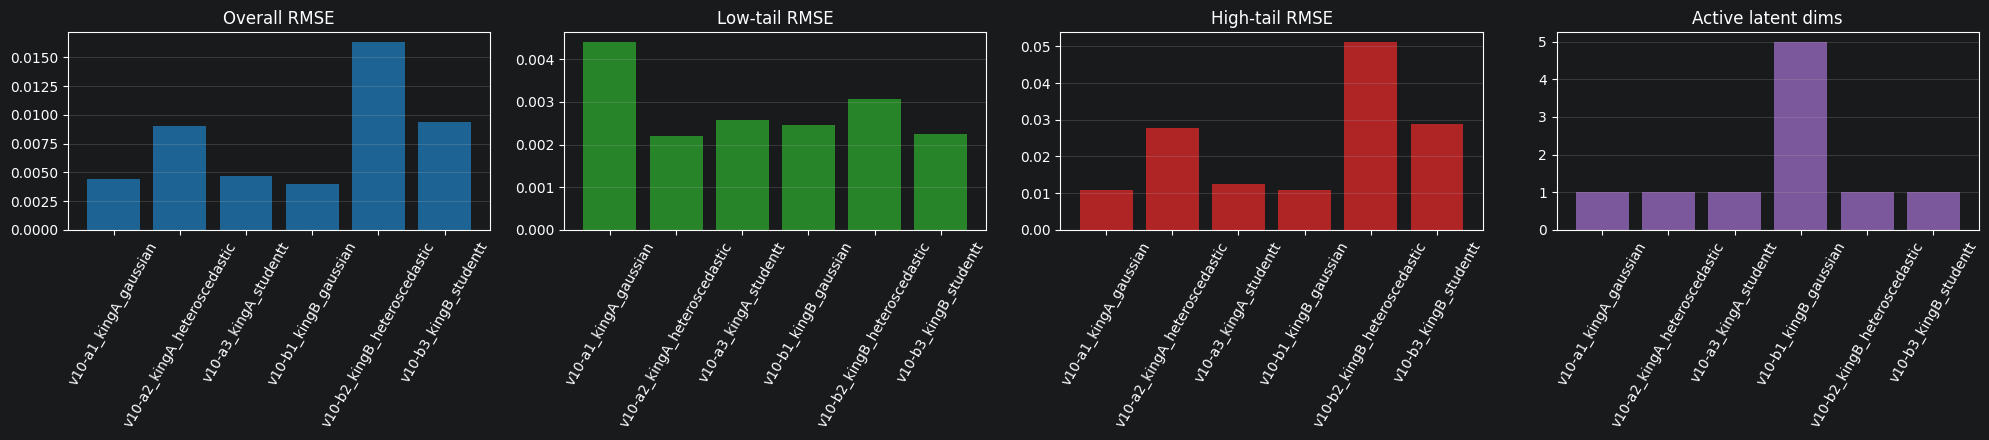

In [6]:
# saving plus compare plots
with open("v10_sweep_results.csv", "w", newline="") as f:
    if sweep_results:
        writer = csv.DictWriter(f, fieldnames=sweep_results[0].keys())
        writer.writeheader()
        writer.writerows(sweep_results)
print("\nSaved full results table to v10_sweep_results.csv")

for r in sweep_results:
    print(r)

if has_test:
    plot_sweep_summary(sweep_results, save_path="v10_plots/sweep_summary.png")


In [7]:
# champ
if has_test:
    winner = min(sweep_results, key=lambda r: r['rmse_overall'])
    print(f"\nBest overall RMSE: {winner['name']}  (RMSE={winner['rmse_overall']:.5f})")
    tail_winner = min(sweep_results, key=lambda r: r['rmse_high_tail'])
    print(f"Best high-tail RMSE: {tail_winner['name']}  (RMSE={tail_winner['rmse_high_tail']:.5f})")
    calib_winner = min(sweep_results, key=lambda r: abs(r['within_1std_pct'] - 0.68))
    print(f"Best calibrated (closest to 68% within 1 std): {calib_winner['name']}  "
          f"({calib_winner['within_1std_pct']:.1%})")


Best overall RMSE: v10-b1_kingB_gaussian  (RMSE=0.00403)
Best high-tail RMSE: v10-b1_kingB_gaussian  (RMSE=0.01078)
Best calibrated (closest to 68% within 1 std): v10-b1_kingB_gaussian  (99.6%)
